In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns


In [2]:
df = pd.read_csv('dados_processados.csv')


In [3]:
# Res: 'H' (casa vence), 'D' (empate), 'A' (fora vence)

df['target'] = df['Res'].map({'H': 0, 'D': 1, 'A': 2})
df['target_bin'] = (df['Res'] == 'H').astype(int) # target alternativa binaria


In [4]:
eps = 1e-6

# criando novas features para agregar prever o alvo
df['home_goal_ratio'] = df['home_last5_goals'] / (df['home_last5_concede'] + eps)
df['away_goal_ratio'] = df['away_last5_goals'] / (df['away_last5_concede'] + eps)


# 1. Diferença de forma ofensiva (casa - fora)

In [5]:
df['diff_goals']       = df['home_last5_goals'] - df['away_last5_goals']
df['diff_winrate']     = df['home_last5_winrate'] - df['away_last5_winrate']
df['diff_ppg']         = df['home_last5_ppg'] - df['away_last5_ppg']

In [6]:
df['diff_goal_ratio_raw']   = df['home_goal_ratio'] - df['away_goal_ratio']
df['ratio_concede_raw']     = df['away_last5_concede'] / (df['home_last5_concede'] + eps)

In [7]:
# Capping percentis 1/99
for col in ['diff_goal_ratio_raw', 'ratio_concede_raw']:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col.replace('_raw', '_capped')] = df[col].clip(lo, hi)

In [8]:
# Log-transform para diff_goal_ratio
df['log_diff_goal_ratio'] = np.log1p(
    df['diff_goal_ratio_capped'] - df['diff_goal_ratio_capped'].min() + 0.01
)

In [9]:
df['diferenca_ajustada'] = df['diff_goals'] / (df['entropy'] + 0.01)

In [10]:
df['dif_draw'] = (df['p_home'] - df['p_draw']) /df['entropy']

In [11]:
form_prob = df["diff_winrate"] * 0.5 + 0.5

# Quem está mais otimista em relação ao mandante forma ou mercado
df["market_form_direction"] = (
    df["p_home"] - form_prob
)

# Quanto mercado e forma discordam
df["market_form_divergence"] = np.abs(
    df["p_home"] - form_prob
)

In [12]:
df.columns

Index(['Date', 'Season', 'Home', 'Away', 'HG', 'AG', 'Res', 'PSCH', 'PSCD',
       'PSCA', 'Date_parsed', 'p_home', 'p_draw', 'p_away', 'dif_prob',
       'dif_draw', 'goal_diff', 'goal_total', 'bucket_favoritismo',
       'home_last5_goals', 'away_last5_goals', 'home_last5_concede',
       'away_last5_concede', 'home_ewma_5_goals', 'away_ewma_5_goals',
       'Res_num', 'home_last5_winrate', 'away_last5_winrate', 'home_points',
       'away_points', 'home_last5_ppg', 'away_last5_ppg', 'entropy', 'target',
       'target_bin', 'home_goal_ratio', 'away_goal_ratio', 'diff_goals',
       'diff_winrate', 'diff_ppg', 'diff_goal_ratio_raw', 'ratio_concede_raw',
       'diff_goal_ratio_capped', 'ratio_concede_capped', 'log_diff_goal_ratio',
       'diferenca_ajustada', 'market_form_direction',
       'market_form_divergence'],
      dtype='str')

In [13]:
FEATURES_FINAIS = [
    # Mercado (2)
    'dif_prob', 
    'entropy',
    'p_home', 'p_draw', 'p_away',
    
    # Forma relativa — diferenças (3)
    'diff_goals', 'diff_winrate', 'diff_ppg',
    
    # Eficiência ofensiva (2)
    'home_goal_ratio', 'away_goal_ratio',
    
    # Vulnerabilidade relativa estabilizada (1)
    'ratio_concede_capped',
    
    # Interação mercado-forma (2) — NOVA
    'market_form_divergence',
    "market_form_direction",
    
    # Eficiência relativa em log (1) — NOVA
    'log_diff_goal_ratio',
    'diferenca_ajustada',
    'home_ewma_5_goals', 'away_ewma_5_goals',
    'dif_draw'
    
]

In [14]:
# colunas extras que queremos conservar para análises posteriores
EXTRA_COLS = ['Home', 'Away','PSCH', 'PSCD', 'PSCA', 'Res']      # odds brutas


In [15]:
df_model = df[FEATURES_FINAIS + ['target_bin', 'Date_parsed'] + EXTRA_COLS].dropna()


df_model = df_model.sort_values('Date_parsed').reset_index(drop=True)

print(f'Linhas para modelear: {len(df_model)}')



Linhas para modelear: 5222


In [16]:
# analisando as features

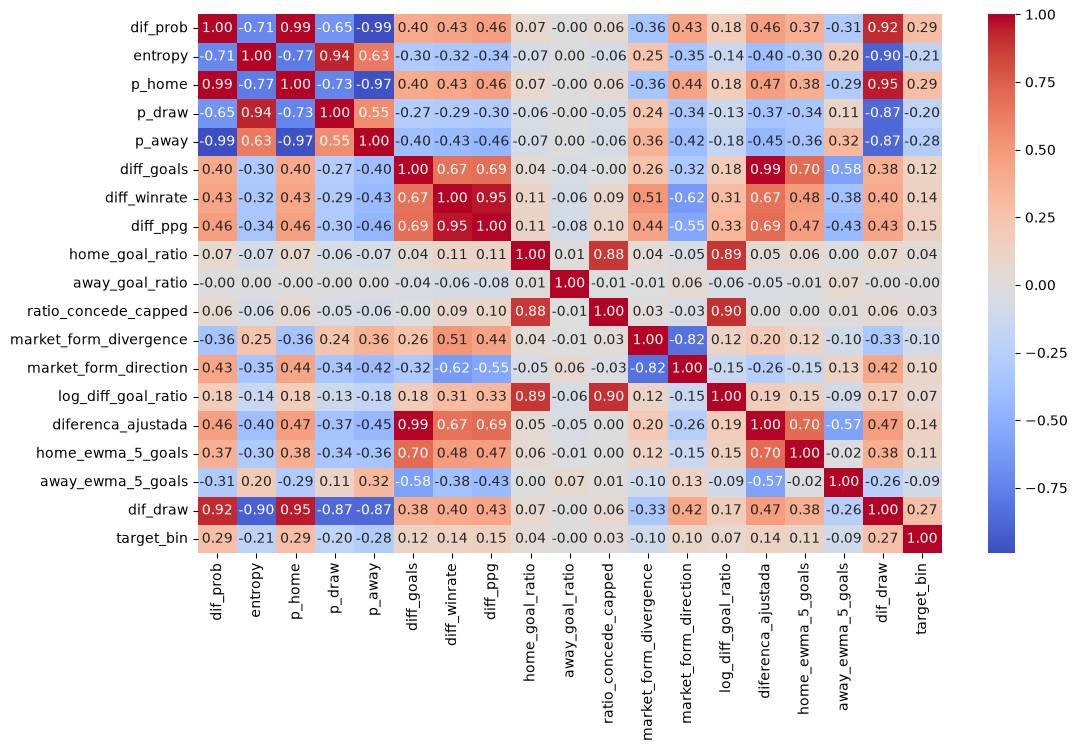

In [17]:
df_test = df[FEATURES_FINAIS + ['target_bin']]
plt.figure(figsize=(12,7))
sns.heatmap(df_test.corr(), annot= True, cmap= 'coolwarm', center = 0, fmt='.2f' )
plt.show()

In [18]:

df_num = df_test.select_dtypes(include=[np.number])
df_num = df_num.dropna()
df_num.shape

(5222, 19)

# separando teste e treino

In [19]:
n = len(df_model)
cut = int( n * 0.8)

X_train = df_model.iloc[:cut][FEATURES_FINAIS]
X_test = df_model.iloc[cut:][FEATURES_FINAIS]
y_train = df_model.iloc[:cut]['target_bin']
y_test = df_model.iloc[cut:]['target_bin']

# TRATAR NAS DA TREINO E TESTE 

In [20]:
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# PERIODO TREINO

In [21]:
# periodo de treino
print(df_model.iloc[0]['Date_parsed'])
print(df_model.iloc[cut-1]['Date_parsed'])

2012-06-06
2023-05-11


# modelo baseline

In [22]:
from sklearn.dummy import DummyClassifier

bm = DummyClassifier()

bm.fit(X_train, y_train)
yp_dummy = bm.predict(X_test)
print(accuracy_score(y_test, yp_dummy))

0.5196172248803828


In [23]:
from sklearn.metrics import accuracy_score, classification_report, log_loss, brier_score_loss

In [24]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

In [25]:
class_weight= {0: 0.5, 1: 1.0 , 2: 1.0}

rf = RandomForestClassifier(n_estimators=100, max_depth=10,class_weight= 'balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

pp_rf = rf.predict_proba(X_test)

y_proba = rf.predict_proba(X_test)[:,1]


print('=== RANDOM FOREST ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf))
print(f"Brier:    {brier_score_loss(y_test, pp_rf[:,1]):.4f}")
print(f"LogLoss:  {log_loss(y_test, pp_rf):.4f}")

auc = roc_auc_score(y_test, y_proba)
print(f'AUC-ROC: {auc:.4f}')


=== RANDOM FOREST ===
Accuracy: 0.5943
              precision    recall  f1-score   support

           0       0.63      0.53      0.58       543
           1       0.57      0.66      0.61       502

    accuracy                           0.59      1045
   macro avg       0.60      0.60      0.59      1045
weighted avg       0.60      0.59      0.59      1045

Brier:    0.2347
LogLoss:  0.6633
AUC-ROC: 0.6432


In [26]:
imp = pd.Series(rf.feature_importances_, index=FEATURES_FINAIS).sort_values(ascending=False)
print("\nFeature Importance:")
print(imp)



Feature Importance:
p_away                    0.097536
dif_prob                  0.093030
p_home                    0.090661
dif_draw                  0.083215
p_draw                    0.062670
away_ewma_5_goals         0.057788
home_ewma_5_goals         0.057501
entropy                   0.056142
diferenca_ajustada        0.052215
market_form_divergence    0.049486
market_form_direction     0.049221
log_diff_goal_ratio       0.049135
ratio_concede_capped      0.048538
away_goal_ratio           0.043593
home_goal_ratio           0.043297
diff_goals                0.025826
diff_ppg                  0.025668
diff_winrate              0.014479
dtype: float64


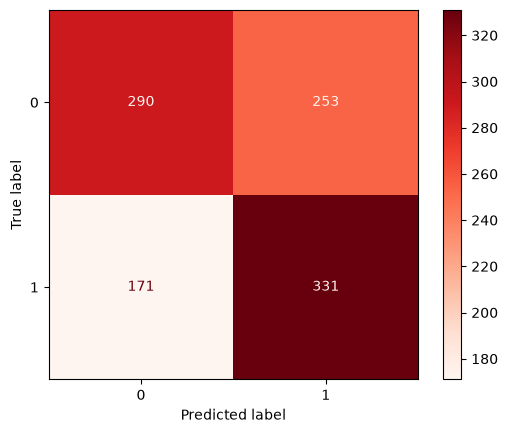

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.show()

In [28]:
df_test = df_model.iloc[cut:].copy()

df_test["prob_modelo"] = pp_rf[:,1]

In [29]:
df_test["prob_modelo"].describe()

count    1045.000000
mean        0.494278
std         0.145985
min         0.039542
25%         0.401839
50%         0.522190
75%         0.586060
max         0.908093
Name: prob_modelo, dtype: float64

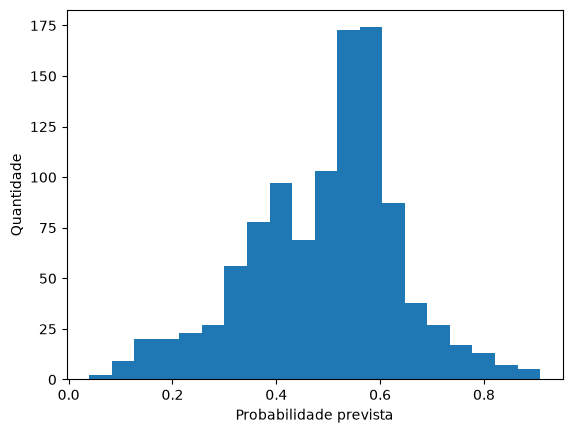

In [30]:
plt.hist(df_test["prob_modelo"], bins=20)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Quantidade")
plt.show()

In [31]:
df_test["prob_mercado"] = df_test["p_home"]

df_test[["prob_modelo","prob_mercado"]].describe()

,prob_modelo,prob_mercado
count,1045.000000,1045.000000
mean,0.494278,0.464022
std,0.145985,0.132549
min,0.039542,0.105966
25%,0.401839,0.368426
50%,0.522190,0.465479
75%,0.586060,0.560000
max,0.908093,0.811883


In [32]:
df_test["edge_modelo"] = (
    df_test["prob_modelo"] -
    df_test["prob_mercado"]
)

In [33]:
df_test[["prob_modelo","prob_mercado"]].corr()

,prob_modelo,prob_mercado
prob_modelo,1.000000,0.865085
prob_mercado,0.865085,1.000000


In [66]:
df_test.sort_values(
    "edge_modelo",
    ascending=True
)[[
    "Home",
    "Away",
    "PSCH",
    "prob_modelo",
    "prob_mercado",
    "Res"
]].head(20)

,Home,Away,PSCH,prob_modelo,prob_mercado,Res
4497,Bragantino,Coritiba,1.20,0.582466,0.806125,H
4312,Atletico-MG,Bahia,1.60,0.414335,0.605622,H
5002,Flamengo RJ,Sao Paulo,1.46,0.471020,0.660759,H
4715,Juventude,Botafogo RJ,3.85,0.090388,0.251309,H
4960,Flamengo RJ,Bahia,1.40,0.527874,0.687032,H
5086,Botafogo RJ,Bragantino,1.63,0.439232,0.592687,H
4553,Flamengo RJ,Corinthians,1.60,0.450075,0.603121,H
4873,Fluminense,Cuiaba,1.38,0.550391,0.703263,H
4876,Cruzeiro,Palmeiras,4.05,0.085769,0.237964,A
4503,Bahia,Atletico-MG,2.50,0.238672,0.389074,H


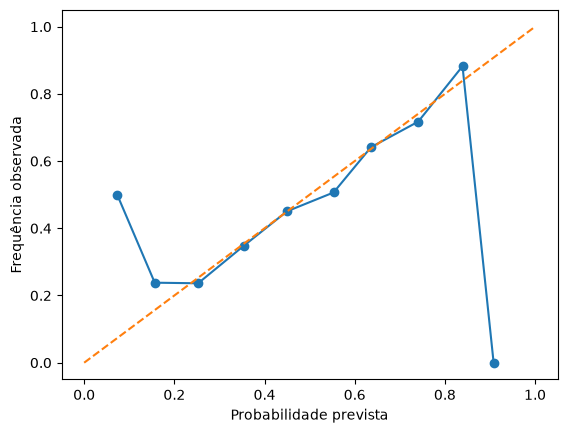

In [35]:
from sklearn.calibration import calibration_curve



prob_true, prob_pred = calibration_curve(
    y_test,
    pp_rf[:,1],
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.show()

<Figure size 600x600 with 0 Axes>

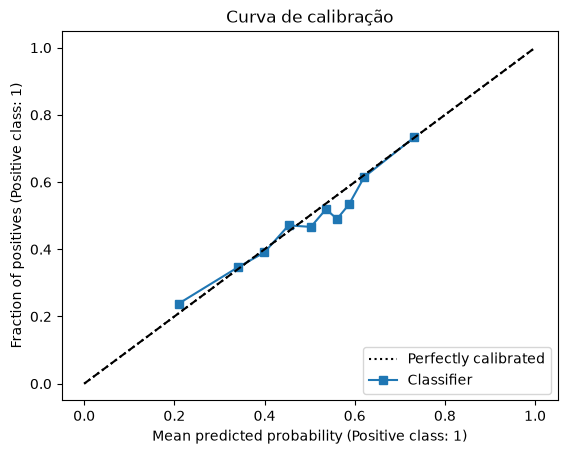

In [36]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

CalibrationDisplay.from_predictions(
    y_test,
    pp_rf[:,1],          # ou y_proba_calib para o modelo calibrado
    n_bins=10,
    strategy="quantile"
)

plt.plot([0,1],[0,1],"k--")
plt.title("Curva de calibração")
plt.show()

In [37]:
df_test["lucro_home"] = np.where(
    df_test["target_bin"] == 1,
    df_test["PSCH"] - 1,   # ganhou a aposta
    -1                     # perdeu a stake
)

In [38]:
df_test["EV"] = df_test["prob_modelo"] * df_test["PSCH"] - 1

for limite in [0.00, 0.05, 0.10, 0.15]:
    apostas = df_test[df_test["EV"] > limite]

    roi = apostas["lucro_home"].mean()

    print(
        f"EV>{limite:.2f} | "
        f"Apostas={len(apostas):4d} | "
        f"ROI={roi:.3f} | "
        f"Acerto={apostas['target_bin'].mean():.3f} | "
        f"Odd média={apostas['PSCH'].mean():.2f} | "
        f"EV médio={apostas['EV'].mean():.3f}"
    )

EV>0.00 | Apostas= 597 | ROI=0.021 | Acerto=0.487 | Odd média=2.32 | EV médio=0.159
EV>0.05 | Apostas= 457 | ROI=0.012 | Acerto=0.464 | Odd média=2.40 | EV médio=0.200
EV>0.10 | Apostas= 315 | ROI=-0.020 | Acerto=0.416 | Odd média=2.57 | EV médio=0.257
EV>0.15 | Apostas= 225 | ROI=-0.046 | Acerto=0.382 | Odd média=2.71 | EV médio=0.312


In [39]:
# ---------- Função para avaliar um filtro qualquer ----------
def avaliar_filtro(df, filtro_nome, condicao):
    """
    Aplica uma condição booleana ao DataFrame e imprime as métricas.
    condicao: uma expressão booleana (ex: df['EV'] > 0.04)
              ou uma função que retorna uma série booleana.
    """
    if callable(condicao):
        mask = condicao(df)
    else:
        mask = condicao
    apostas = df[mask]
    if len(apostas) == 0:
        print(f"{filtro_nome}: Nenhuma aposta encontrada.")
        return
    roi = apostas["lucro_home"].mean()
    acerto = apostas["target_bin"].mean()
    odd_media = apostas["PSCH"].mean()
    ev_medio = apostas["EV"].mean()
    print(f"{filtro_nome:30s} | "
          f"Apostas={len(apostas):4d} | "
          f"ROI={roi:6.3f} | "
          f"Acerto={acerto:6.3f} | "
          f"Odd média={odd_media:6.2f} | "
          f"EV médio={ev_medio:6.3f}")

# ---------- 1. Filtro sugerido: EV entre 0.04 e 0.10 ----------
avaliar_filtro(
    df_test,
    "EV 0.04 ~ 0.10 (puro)",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.10)
)

# ---------- 2. EV entre 0.04 e 0.10 + Probabilidade >= 0.35 ----------
avaliar_filtro(
    df_test,
    "EV 0.04~0.10 + prob>=0.35",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.10) & (df_test["prob_modelo"] >= 0.35)
)

# ---------- 3. EV entre 0.04 e 0.10 + Odd máxima 3.80 ----------
avaliar_filtro(
    df_test,
    "EV 0.04~0.10 + odd<=3.80",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.10) & (df_test["PSCH"] <= 3.80)
)

# ---------- 4. Combinação: EV 0.03~0.09 (mais volume) ----------
avaliar_filtro(
    df_test,
    "EV 0.03 ~ 0.09 + prob>=0.33",
    (df_test["EV"] > 0.03) & (df_test["EV"] < 0.09) & (df_test["prob_modelo"] >= 0.33)
)

# ---------- 5. Teste do melhor bucket calibrado (EV >0.05) com odds limitada ----------
avaliar_filtro(
    df_test,
    "EV>0.05 + odd<=3.80",
    (df_test["EV"] > 0.05) & (df_test["PSCH"] <= 3.80)
)

# ---------- 6. Filtro ainda mais restrito (EV 0.04~0.08 + prob>=0.38 + odd<=3.50) ----------
avaliar_filtro(
    df_test,
    "EV 0.04~0.08 + prob>=0.38 + odd<=3.50",
    (df_test["EV"] > 0.04) & (df_test["EV"] < 0.08) &
    (df_test["prob_modelo"] >= 0.38) & (df_test["PSCH"] <= 3.50)
)

EV 0.04 ~ 0.10 (puro)          | Apostas= 176 | ROI= 0.073 | Acerto= 0.568 | Odd média=  2.01 | EV médio= 0.068
EV 0.04~0.10 + prob>=0.35      | Apostas= 170 | ROI= 0.110 | Acerto= 0.588 | Odd média=  1.94 | EV médio= 0.068
EV 0.04~0.10 + odd<=3.80       | Apostas= 175 | ROI= 0.079 | Acerto= 0.571 | Odd média=  1.97 | EV médio= 0.068
EV 0.03 ~ 0.09 + prob>=0.33    | Apostas= 171 | ROI= 0.115 | Acerto= 0.596 | Odd média=  1.94 | EV médio= 0.058
EV>0.05 + odd<=3.80            | Apostas= 440 | ROI= 0.003 | Acerto= 0.473 | Odd média=  2.27 | EV médio= 0.184
EV 0.04~0.08 + prob>=0.38 + odd<=3.50 | Apostas= 112 | ROI= 0.085 | Acerto= 0.598 | Odd média=  1.89 | EV médio= 0.058


In [40]:
df_teste_temporal = df_test.sort_values('Date_parsed').tail(int(len(df)*0.2))

filtro_f6 = (
    (df_teste_temporal['EV'] > 0.04) &
    (df_teste_temporal['EV'] < 0.08) &
    (df_teste_temporal['prob_modelo'] >= 0.38) &
    (df_teste_temporal['PSCH'] <= 3.50)
)

apostas_f6_temporal = df_teste_temporal[filtro_f6]

roi_temporal = apostas_f6_temporal['lucro_home'].mean()
print(f"ROI no período recente (validação): {roi_temporal:.3f}")
print(f"Apostas: {len(apostas_f6_temporal)}")

ROI no período recente (validação): 0.085
Apostas: 112


# Calibrar as Probabilidades

In [55]:

from sklearn.calibration import CalibratedClassifierCV

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_cal = CalibratedClassifierCV(
    estimator=rf,
    method= "isotonic",        #  "isotonic",   # ou "sigmoid"
    cv=5
)

rf_cal.fit(X_train, y_train)

y_proba_calib = rf_cal.predict_proba(X_test)[:,1]

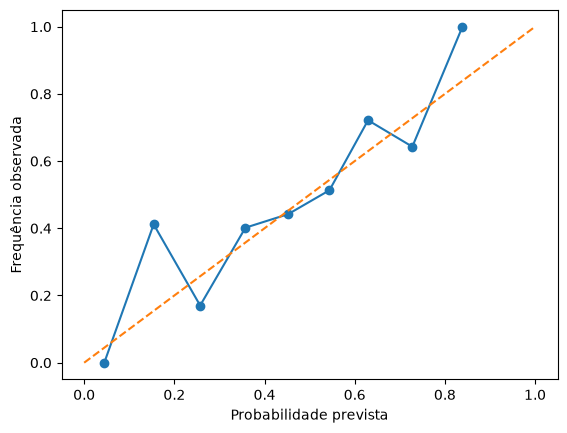

In [56]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba_calib,
    n_bins=10
)

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidade prevista")
plt.ylabel("Frequência observada")
plt.show()

<Figure size 600x600 with 0 Axes>

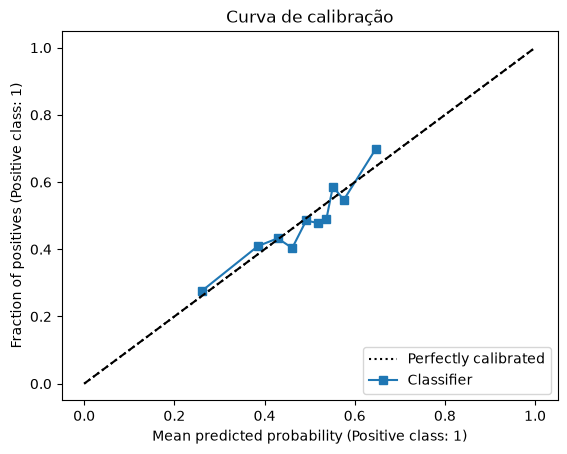

In [57]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

CalibrationDisplay.from_predictions(
    y_test,
    y_proba_calib,          # ou y_proba_calib para o modelo calibrado
    n_bins=10,
    strategy="quantile"
)

plt.plot([0,1],[0,1],"k--")
plt.title("Curva de calibração")
plt.show()

In [58]:
print(f"Brier:    {brier_score_loss(y_test, y_proba_calib):.4f}")
print(f"LogLoss:  {log_loss(y_test, y_proba_calib):.4f}")

auc = roc_auc_score(y_test, y_proba_calib)
print(f'AUC-ROC: {auc:.4f}')

Brier:    0.2399
LogLoss:  0.6732
AUC-ROC: 0.6153


In [59]:
df_calib = df_model.iloc[cut:].copy()

df_calib["prob_modelo"] = y_proba_calib

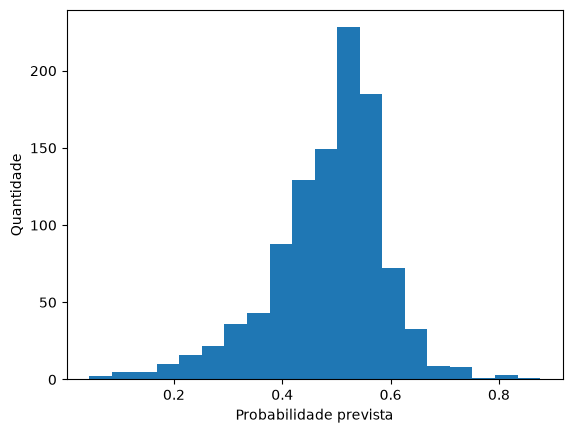

In [60]:
plt.hist(df_calib["prob_modelo"], bins=20)
plt.xlabel("Probabilidade prevista")
plt.ylabel("Quantidade")
plt.show()

In [61]:
df_calib['prob_mercado'] = df_calib['p_home']

df_calib[['prob_mercado', 'prob_modelo']].describe()

,prob_mercado,prob_modelo
count,1045.000000,1045.000000
mean,0.464022,0.485605
std,0.132549,0.107248
min,0.105966,0.043529
25%,0.368426,0.429860
50%,0.465479,0.507523
75%,0.560000,0.549512
max,0.811883,0.875976


In [62]:
df_calib[['prob_modelo', 'prob_mercado']].corr()

,prob_modelo,prob_mercado
prob_modelo,1.000000,0.755729
prob_mercado,0.755729,1.000000


In [63]:
df_calib['edge_modelo'] = (
    df_calib['prob_modelo'] -
    df_calib['prob_mercado']
)

In [65]:
df_calib.sort_values(
    "edge_modelo",
    ascending=True
)[[
    "Home",
    "Away",
    "PSCH",
    "prob_modelo",
    "prob_mercado",
    "Res"
]].head(20)

,Home,Away,PSCH,prob_modelo,prob_mercado,Res
4497,Bragantino,Coritiba,1.20,0.536382,0.806125,H
4936,Internacional,Juventude,1.40,0.470032,0.685956,H
4960,Flamengo RJ,Bahia,1.40,0.472491,0.687032,H
4873,Fluminense,Cuiaba,1.38,0.499846,0.703263,H
4553,Flamengo RJ,Corinthians,1.60,0.404780,0.603121,H
4312,Atletico-MG,Bahia,1.60,0.415798,0.605622,H
4970,Juventude,Fluminense,4.11,0.045714,0.235353,D
5207,Bahia,Sport Recife,1.20,0.615828,0.798990,H
4912,Bahia,Mirassol,1.50,0.462248,0.642331,D
4352,Palmeiras,Goias,1.29,0.572919,0.752009,H


In [67]:
df_calib["lucro_home"] = np.where(
    df_test["target_bin"] == 1,
    df_test["PSCH"] - 1,   # ganhou a aposta
    -1                     # perdeu a stake
)

In [68]:
df_calib["EV"] = df_calib["prob_modelo"] * df_calib["PSCH"] - 1

for limite in [0.00, 0.05, 0.10, 0.15]:
    apostas = df_calib[df_calib["EV"] > limite]

    roi = apostas["lucro_home"].mean()

    print(
        f"EV>{limite:.2f} | "
        f"Apostas={len(apostas):4d} | "
        f"ROI={roi:.3f} | "
        f"Acerto={apostas['target_bin'].mean():.3f} | "
        f"Odd média={apostas['PSCH'].mean():.2f} | "
        f"EV médio={apostas['EV'].mean():.3f}"
    )

EV>0.00 | Apostas= 558 | ROI=-0.065 | Acerto=0.391 | Odd média=2.65 | EV médio=0.213
EV>0.05 | Apostas= 459 | ROI=-0.114 | Acerto=0.355 | Odd média=2.74 | EV médio=0.253
EV>0.10 | Apostas= 372 | ROI=-0.106 | Acerto=0.341 | Odd média=2.86 | EV médio=0.295
EV>0.15 | Apostas= 283 | ROI=-0.116 | Acerto=0.325 | Odd média=3.00 | EV médio=0.348


In [69]:
# ---------- Função para avaliar um filtro qualquer ----------
def avaliar_filtro(df, filtro_nome, condicao):
    """
    Aplica uma condição booleana ao DataFrame e imprime as métricas.
    condicao: uma expressão booleana (ex: df['EV'] > 0.04)
              ou uma função que retorna uma série booleana.
    """
    if callable(condicao):
        mask = condicao(df)
    else:
        mask = condicao
    apostas = df[mask]
    if len(apostas) == 0:
        print(f"{filtro_nome}: Nenhuma aposta encontrada.")
        return
    roi = apostas["lucro_home"].mean()
    acerto = apostas["target_bin"].mean()
    odd_media = apostas["PSCH"].mean()
    ev_medio = apostas["EV"].mean()
    print(f"{filtro_nome:30s} | "
          f"Apostas={len(apostas):4d} | "
          f"ROI={roi:6.3f} | "
          f"Acerto={acerto:6.3f} | "
          f"Odd média={odd_media:6.2f} | "
          f"EV médio={ev_medio:6.3f}")

# ---------- 1. Filtro sugerido: EV entre 0.04 e 0.10 ----------
avaliar_filtro(
    df_calib,
    "EV 0.04 ~ 0.10 (puro)",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.10)
)

# ---------- 2. EV entre 0.04 e 0.10 + Probabilidade >= 0.35 ----------
avaliar_filtro(
    df_calib,
    "EV 0.04~0.10 + prob>=0.35",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.10) & (df_calib["prob_modelo"] >= 0.35)
)

# ---------- 3. EV entre 0.04 e 0.10 + Odd máxima 3.80 ----------
avaliar_filtro(
    df_calib,
    "EV 0.04~0.10 + odd<=3.80",
    (df_test["EV"] > 0.04) & (df_calib["EV"] < 0.10) & (df_calib["PSCH"] <= 3.80)
)

# ---------- 4. Combinação: EV 0.03~0.09 (mais volume) ----------
avaliar_filtro(
    df_calib,
    "EV 0.03 ~ 0.09 + prob>=0.33",
    (df_calib["EV"] > 0.03) & (df_calib["EV"] < 0.09) & (df_calib["prob_modelo"] >= 0.33)
)

# ---------- 5. Teste do melhor bucket calibrado (EV >0.05) com odds limitada ----------
avaliar_filtro(
    df_calib,
    "EV>0.05 + odd<=3.80",
    (df_calib["EV"] > 0.05) & (df_calib["PSCH"] <= 3.80)
)

# ---------- 6. Filtro ainda mais restrito (EV 0.04~0.08 + prob>=0.38 + odd<=3.50) ----------
avaliar_filtro(
    df_calib,
    "EV 0.04~0.08 + prob>=0.38 + odd<=3.50",
    (df_calib["EV"] > 0.04) & (df_calib["EV"] < 0.08) &
    (df_calib["prob_modelo"] >= 0.38) & (df_calib["PSCH"] <= 3.50)
)

EV 0.04 ~ 0.10 (puro)          | Apostas= 104 | ROI=-0.122 | Acerto= 0.423 | Odd média=  2.23 | EV médio= 0.071
EV 0.04~0.10 + prob>=0.35      | Apostas=  96 | ROI=-0.115 | Acerto= 0.438 | Odd média=  2.11 | EV médio= 0.071
EV 0.04~0.10 + odd<=3.80       | Apostas= 204 | ROI= 0.089 | Acerto= 0.608 | Odd média=  1.83 | EV médio=-0.001
EV 0.03 ~ 0.09 + prob>=0.33    | Apostas=  93 | ROI=-0.064 | Acerto= 0.462 | Odd média=  2.09 | EV médio= 0.059
EV>0.05 + odd<=3.80            | Apostas= 422 | ROI=-0.096 | Acerto= 0.374 | Odd média=  2.53 | EV médio= 0.228
EV 0.04~0.08 + prob>=0.38 + odd<=3.50 | Apostas=  60 | ROI=-0.115 | Acerto= 0.450 | Odd média=  2.05 | EV médio= 0.061


In [70]:
df_teste_temporal = df_calib.sort_values('Date_parsed').tail(int(len(df)*0.2))

filtro_f6 = (
    (df_teste_temporal['EV'] > 0.04) &
    (df_teste_temporal['EV'] < 0.08) &
    (df_teste_temporal['prob_modelo'] >= 0.38) &
    (df_teste_temporal['PSCH'] <= 3.50)
)

apostas_f6_temporal = df_teste_temporal[filtro_f6]

roi_temporal = apostas_f6_temporal['lucro_home'].mean()
print(f"ROI no período recente (validação): {roi_temporal:.3f}")
print(f"Apostas: {len(apostas_f6_temporal)}")

ROI no período recente (validação): -0.115
Apostas: 60
